In [1]:
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import re

## Configuración W&B

In [2]:
#Instalar W&B
!pip install wandb -q

In [3]:
#Login  W&B
from google.colab import userdata
import wandb

wandb.login(key=userdata.get("WANDB_API_KEY"))


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: crismur93 (natamoncada10-universidad-de-los-andes) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
#Prueba mínima de conexión  W&B
run = wandb.init(
    project="maia-flag-document-analysis",
    entity="natamoncada10-universidad-de-los-andes",
    name="test-connection-nata",
    tags=["test", "setup"],
    config={
        "purpose": "validar conexion inicial",
        "owner": "nata"
    }
)

wandb.log({"test_metric": 1.0})
wandb.finish()

test_metric,▁
test_metric,1


# Preparación del Dataset Combinado
> 🆕 **Celdas agregadas** — Unen los dos batches de autoetiquetado generados por Edwin, eliminan duplicados y submuestrean las clases con más de 1800 snippets para balancear el dataset antes del EDA y entrenamiento.

In [5]:
# [NUEVA CELDA] Union de batches con priorizacion de batch3 y batch4
# ==========================================
# Estrategia de Cristian:
# 1. Priorizar batch3 y batch4 (mejor calidad, regex mejorada)
# 2. Completar con batch1 y batch2 donde falten snippets
# 3. Agregar CONTR de Edwin
# 4. Eliminar duplicados
# ==========================================

COLS = ['source_file', 'category', 'snippet', 'word_count', 'matched_keywords', 'regex_score']
TARGET_PER_CLASS = 1800

# --- 1. Cargar todos los batches ---
unified_csv = './etiquetas_manuales_unificadas.csv'
batch1 = pd.read_csv('./auto_labeled_output.csv')[COLS]
batch2 = pd.read_csv('./auto_labeled_output_batch2.csv')[COLS]
batch3 = pd.read_csv('./auto_labeled_output_batch3.csv')[COLS]
batch4 = pd.read_csv('./auto_labeled_output_batch4.csv')[COLS]

print(f"Batch 1: {len(batch1)} snippets")
print(f"Batch 2: {len(batch2)} snippets")
print(f"Batch 3: {len(batch3)} snippets")
print(f"Batch 4: {len(batch4)} snippets")

# --- 2. Cargar y alinear CONTR de Edwin ---
contr_df = pd.read_csv('./train_test_1800_CONTR.csv')
contr_df['word_count'] = contr_df['snippet'].apply(lambda x: len(str(x).split()))
contr_df['matched_keywords'] = contr_df['keywords']
contr_df['regex_score'] = 0
contr_df = contr_df[COLS]
print(f"CONTR (Edwin): {len(contr_df)} snippets")

# --- 3. Priorizar batch3 y batch4 ---
# Estos tienen mejor calidad por las regex mejoradas y filtros de documentos
priority = pd.concat([batch3, batch4], ignore_index=True)
priority = priority.drop_duplicates(subset=['snippet'])
print(f"Prioritarios (batch3 + batch4): {len(priority)} snippets")

# --- 4. Complementar con batch1 y batch2 donde falten snippets ---
fallback = pd.concat([batch1, batch2], ignore_index=True)
fallback = fallback.drop_duplicates(subset=['snippet'])
print(f"Fallback (batch1 + batch2): {len(fallback)} snippets")

# Excluir snippets que ya están en priority
files_in_priority = set(priority['source_file'].unique())
fallback = fallback[~fallback['source_file'].isin(files_in_priority)]
fallback = fallback[~fallback['snippet'].isin(priority['snippet'])]
print(f"Fallback (sin priority): {len(fallback)} snippets")

print("\nDistribucion en batches prioritarios (3+4):")
print(priority['category'].value_counts())

supplemented = []
for cat in priority['category'].unique():
    cat_priority = priority[priority['category'] == cat]
    needed = TARGET_PER_CLASS - len(cat_priority)
    if needed > 0:
        cat_fallback = fallback[fallback['category'] == cat].head(needed)
        supplemented.append(pd.concat([cat_priority, cat_fallback]))
        print(f"{cat}: {len(cat_priority)} priority + {len(cat_fallback)} fallback = {len(cat_priority)+len(cat_fallback)}")
    else:
        supplemented.append(cat_priority)
        print(f"{cat}: {len(cat_priority)} priority (no fallback needed)")

# Agregar categorias que solo estan en batch1/2 (si las hay)
cats_in_priority = set(priority['category'].unique())
cats_in_fallback = set(fallback['category'].unique())
missing_cats = cats_in_fallback - cats_in_priority
for cat in missing_cats:
    cat_data = fallback[fallback['category'] == cat].head(TARGET_PER_CLASS)
    supplemented.append(cat_data)
    print(f"{cat}: {len(cat_data)} (solo en fallback)")

combined = pd.concat(supplemented + [contr_df], ignore_index=True)
combined = combined.drop_duplicates(subset=['snippet'])

print(f"\nDataset combinado total: {len(combined)} snippets")
print("\nDistribucion final antes del submuestreo:")
print(combined['category'].value_counts())


Batch 1: 3911 snippets
Batch 2: 15117 snippets
Batch 3: 7155 snippets
Batch 4: 2571 snippets
CONTR (Edwin): 1800 snippets
Prioritarios (batch3 + batch4): 9726 snippets
Fallback (batch1 + batch2): 19025 snippets
Fallback (sin priority): 19025 snippets

Distribucion en batches prioritarios (3+4):
category
INTRO    2485
RES      1631
CONC     1501
BACK     1241
LIM      1129
DISC      924
METH      815
Name: count, dtype: int64
CONC: 1501 priority + 299 fallback = 1800
INTRO: 2485 priority (no fallback needed)
RES: 1631 priority + 169 fallback = 1800
DISC: 924 priority + 876 fallback = 1800
BACK: 1241 priority + 559 fallback = 1800
METH: 815 priority + 985 fallback = 1800
LIM: 1129 priority + 671 fallback = 1800

Dataset combinado total: 15085 snippets

Distribucion final antes del submuestreo:
category
INTRO    2485
CONC     1800
RES      1800
DISC     1800
BACK     1800
METH     1800
LIM      1800
CONTR    1800
Name: count, dtype: int64


In [6]:
# [NUEVA CELDA] Submuestreo para balancear clases
# ==========================================
# Las clases con mas de 1800 snippets se limitan a 1800 por conjunto de entrenamiento.
# Las clases con menos se dejan como estan.
# ==========================================

MAX_PER_CLASS = 1800

balanced = (
    combined
    .groupby('category', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), MAX_PER_CLASS), random_state=42))
    .reset_index(drop=True)
)

balanced.to_csv('./training_ready_dataset.csv', index=False)

print("Distribucion final del dataset balanceado:")
print(balanced['category'].value_counts())
print(f"\nTotal de snippets: {len(balanced)}")
print("\nGuardado como training_ready_dataset.csv")


/tmp/ipykernel_6175/4007643279.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), MAX_PER_CLASS), random_state=42))


Distribucion final del dataset balanceado:
category
BACK     1800
CONC     1800
CONTR    1800
DISC     1800
INTRO    1800
LIM      1800
METH     1800
RES      1800
Name: count, dtype: int64

Total de snippets: 14400

Guardado como training_ready_dataset.csv


# Análisis Exploratorio de Datos


> 🆕 **Nota** — El EDA se corre sobre `training_ready_dataset.csv` (dataset combinado y balanceado), no sobre el batch individual original.

--- EDA REPORT ---
Successfully loaded dataset: 14400 total snippets.

1. CLASS DISTRIBUTION
------------------------------
category
BACK     1800
CONC     1800
CONTR    1800
DISC     1800
INTRO    1800
LIM      1800
METH     1800
RES      1800
Name: count, dtype: int64




/tmp/ipykernel_3328/2546017314.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category', order=class_counts.index, palette='viridis')


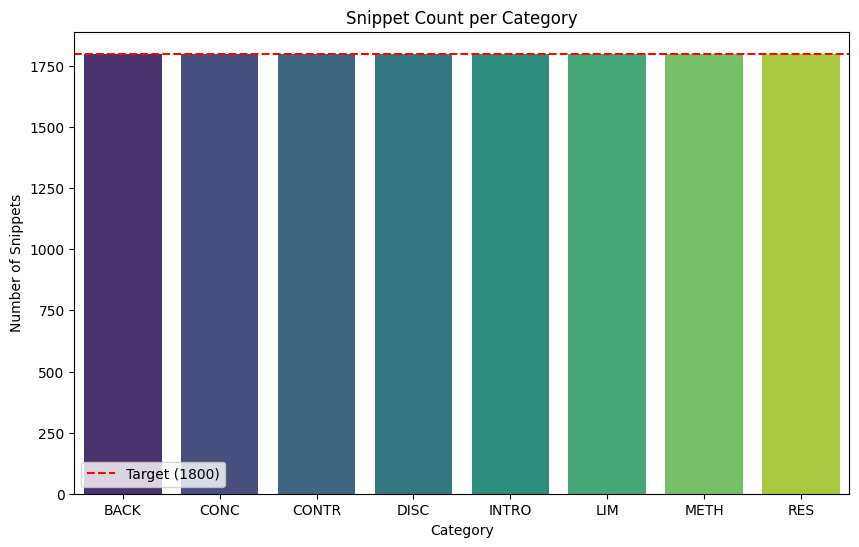


2. WORD COUNT CONSTRAINTS
------------------------------
count    14400.000000
mean       718.764792
std        192.921637
min        250.000000
25%        741.000000
50%        748.000000
75%        750.000000
max       1000.000000
Name: word_count, dtype: float64

SUCCESS: All snippets are strictly within the 250 - 1000 word limit.


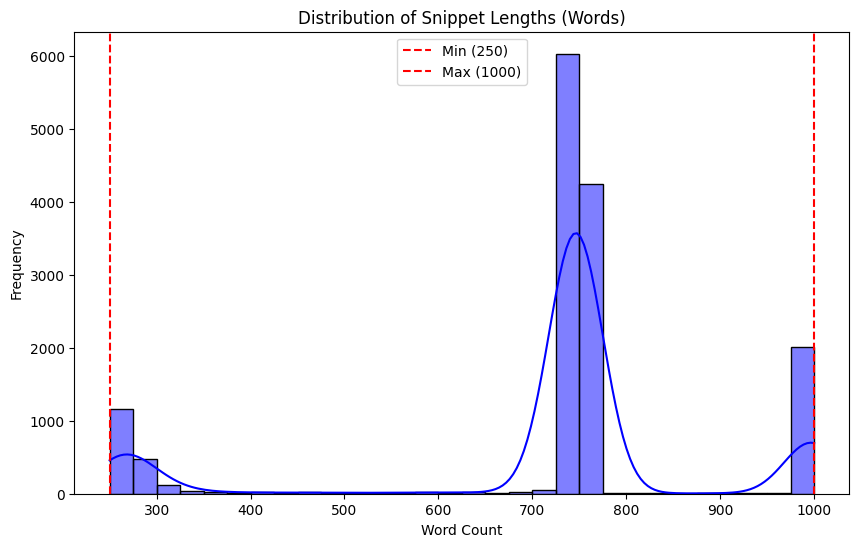


3. REGEX SCORE (CONFIDENCE)
------------------------------
category
BACK     4.24
CONC     2.96
CONTR    0.00
DISC     2.66
INTRO    3.07
LIM      3.06
METH     7.15
RES      6.88
Name: regex_score, dtype: float64

4. WORD COUNT BY CATEGORY (Length Bias Check)
------------------------------


/tmp/ipykernel_3328/2546017314.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='word_count', palette='Set2')


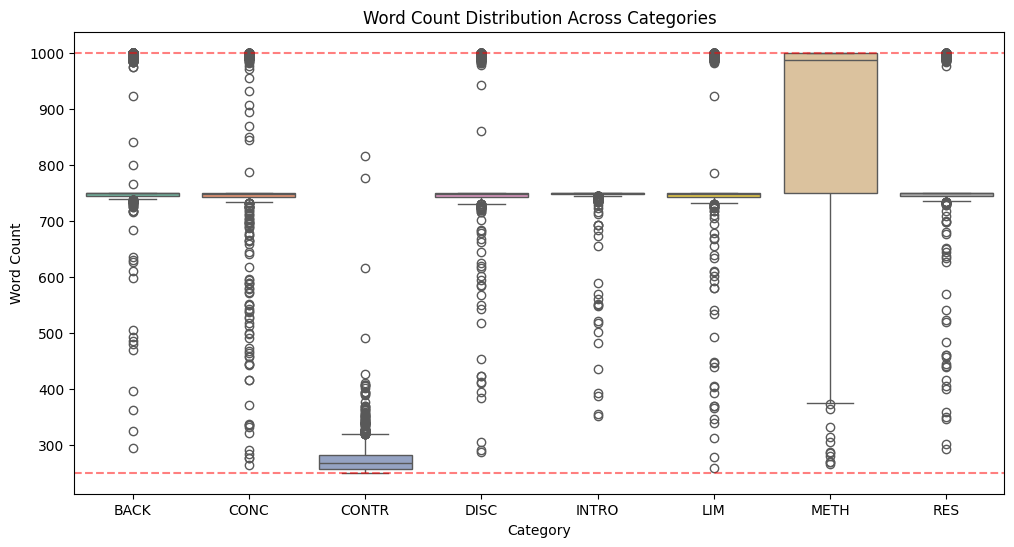


5. KEYWORD DIVERSITY
------------------------------

Top 5 triggers for BACK:
  - 'según el': 646 times
  - 'según la': 566 times
  - 'antecedentes': 475 times
  - 'marco teórico': 292 times
  - 'según los': 256 times

Top 5 triggers for CONC:
  - 'conclusiones': 1086 times
  - 'conclusión': 484 times
  - 'finalmente': 440 times
  - 'se recomienda': 305 times
  - 'se concluye que': 181 times

Top 5 triggers for CONTR:
  - 'trabajo': 127 times
  - 'educación': 118 times
  - 'estudio': 60 times
  - 'investigación': 55 times
  - 'desarrollo': 51 times

Top 5 triggers for DISC:
  - 'discusión': 957 times
  - 'a diferencia de': 251 times
  - 'interpretación de': 205 times
  - 'consecuencia de': 192 times
  - 'a la luz de': 175 times

Top 5 triggers for INTRO:
  - 'introducción': 1521 times
  - 'justificación': 663 times
  - 'objetivo general': 515 times
  - 'planteamiento del problema': 257 times
  - 'el objetivo de este': 183 times

Top 5 triggers for LIM:
  - 'falta de': 1092 times
  - '

In [ ]:
def run_eda(input_csv):
    """
    Performs Exploratory Data Analysis on the auto-labeled dataset
    to ensure it meets the project constraints before training.
    """
    try:
        df = pd.read_csv(input_csv)
        print(f"--- EDA REPORT ---")
        print(f"Successfully loaded dataset: {len(df)} total snippets.\n")
    except FileNotFoundError:
        print(f"Error: Could not find {input_csv}")
        return

    # CLASS BALANCE ANALYSIS
    print("1. CLASS DISTRIBUTION")
    print("-" * 30)
    class_counts = df['category'].value_counts()
    print(class_counts)
    print("\n")

    # Plot Class Distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='category', order=class_counts.index, palette='viridis')
    plt.title('Snippet Count per Category')
    plt.ylabel('Number of Snippets')
    plt.xlabel('Category')
    plt.axhline(y=TARGET_PER_CLASS, color='r', linestyle='--', label=f'Target ({TARGET_PER_CLASS})')
    plt.legend()
    # plt.savefig('eda_class_distribution.png')
    # plt.close()
    # print("-> Saved class distribution plot as 'eda_class_distribution.png'")
    plt.show()

    # WORD COUNT CONSTRAINTS (Crucial for your project)
    print("\n2. WORD COUNT CONSTRAINTS")
    print("-" * 30)
    print(df['word_count'].describe())

    # Check for violations (below 250 or above 1000)
    violations = df[(df['word_count'] < 250) | (df['word_count'] > 1000)]
    if not violations.empty:
        print(f"\nWARNING: Found {len(violations)} snippets that violate the 250-1000 word limit!")
        print("Please check these source files:")
        print(violations[['source_file', 'category', 'word_count']].head())
    else:
        print("\nSUCCESS: All snippets are strictly within the 250 - 1000 word limit.")

    # Plot Word Count Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x='word_count', bins=30, kde=True, color='blue')
    plt.title('Distribution of Snippet Lengths (Words)')
    plt.xlabel('Word Count')
    plt.ylabel('Frequency')
    plt.axvline(x=250, color='r', linestyle='--', label='Min (250)')
    plt.axvline(x=1000, color='r', linestyle='--', label='Max (1000)')
    plt.legend()
    # plt.savefig('eda_word_count.png')
    # plt.close()
    # print("-> Saved word count distribution plot as 'eda_word_count.png'")
    plt.show()

    # REGEX CONFIDENCE (Are we matching enough words?)
    print("\n3. REGEX SCORE (CONFIDENCE)")
    print("-" * 30)
    avg_score_per_class = df.groupby('category')['regex_score'].mean().round(2)
    print(avg_score_per_class)

    # WORD COUNT BY CATEGORY (Checking for Length Bias)
    print("\n4. WORD COUNT BY CATEGORY (Length Bias Check)")
    print("-" * 30)
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='category', y='word_count', palette='Set2')
    plt.title('Word Count Distribution Across Categories')
    plt.ylabel('Word Count')
    plt.xlabel('Category')
    plt.axhline(y=250, color='r', linestyle='--', alpha=0.5)
    plt.axhline(y=1000, color='r', linestyle='--', alpha=0.5)
    plt.show()

    # KEYWORD DIVERSITY (What is triggering the regex?)
    print("\n5. KEYWORD DIVERSITY")
    print("-" * 30)
    for category in df['category'].unique():
        cat_df = df[df['category'] == category]
        all_kws = []
        for kw_string in cat_df['matched_keywords'].dropna():
            # Split by comma and clean
            kws = [k.strip() for k in kw_string.split(',') if k.strip()]
            all_kws.extend(kws)

        top_kws = Counter(all_kws).most_common(5)
        print(f"\nTop 5 triggers for {category}:")
        for kw, count in top_kws:
            print(f"  - '{kw}': {count} times")

    # DATA INTEGRITY (Duplicates & Nulls)
    print("\n6. DATA INTEGRITY CHECKS")
    print("-" * 30)

    # Check for empty snippets
    null_snippets = df['snippet'].isnull().sum()
    print(f"Null/Empty snippets: {null_snippets}")

    # Check for exact duplicate snippets (could happen if a PDF was read twice)
    duplicate_snippets = df.duplicated(subset=['snippet']).sum()
    print(f"Exact duplicate snippets: {duplicate_snippets}")
    if duplicate_snippets > 0:
        print("  -> Consider dropping duplicates: df.drop_duplicates(subset=['snippet'])")

    # Check for files that accidentally got assigned multiple categories
    # (Our script prevents this, but good to double check)
    files_with_multiple_cats = df.groupby('source_file')['category'].nunique()
    multi_cat_files = files_with_multiple_cats[files_with_multiple_cats > 1].count()
    print(f"Files contributing to more than one category: {multi_cat_files} (Should ideally be low/zero for strict separation)")

    # QUICK AUDIT
    print("\n7. QUICK AUDIT (Top 2 highest scoring snippets)")
    print("-" * 30)
    top_snippets = df.sort_values(by='regex_score', ascending=False).head(2)
    for index, row in top_snippets.iterrows():
        print(f"File: {row['source_file']} | Category: {row['category']}")
        print(f"Keywords Matched: {row['matched_keywords']}")
        print(f"Score: {row['regex_score']}\n")

# ==========================================
# EXECUTION
# ==========================================
# Run this on your output from the auto-labeler
run_eda('training_ready_dataset.csv')  # [MODIFICADO] apunta al dataset combinado y balanceado

# Entrenamiento

## Neutralization Snippets

> 🆕 **Nota** — La neutralizacion se aplica sobre el dataset combinado y balanceado.

In [7]:
USE_SOFT_MASK = False

def neutralize_snippets(
        input_csv,
        output_csv,
        keyword_col="matched_keywords",
        mask_token="[MASK]",
        use_soft_mask=False
    ):
    """
    Reads the auto-labeled dataset, finds the matched keywords in the snippet,
    and replaces them with a neutral token to prevent data leakage during training.
    If use_soft_mask is True, it uses a predefined list of explicit headers.
    If False, it uses the dynamically matched keywords from the CSV.
    """
    try:
        df = pd.read_csv(input_csv)
        print(f"Loaded dataset with {len(df)} rows.")
    except FileNotFoundError:
        print(f"Error: Could not find {input_csv}")
        return

    # Ensure the required columns exist
    if 'snippet' not in df.columns or keyword_col not in df.columns:
        print(f"Error: The CSV must contain 'snippet' and '{keyword_col}' columns.")
        return

    # --- LISTA PREDEFINIDA DE SOFT MASK ---
    # Incluye las variaciones con y sin tilde. re.IGNORECASE se encargará de las mayúsculas.
    SOFT_MASK_KEYWORDS = [
        'introducción', 'introduccion', 'objetivos', 'justificacion', 'justificación',
        'antecedentes', 'estado del arte', 'metodología', 'metodologia',
        'materiales y métodos', 'resultados', 'discusión', 'discusion',
        'conclusiones', 'trabajo futuro', 'limitaciones', 'recomendaciones'
    ]
    # CRÍTICO: Ordenar por longitud descendente para evitar reemplazos parciales
    SOFT_MASK_KEYWORDS.sort(key=len, reverse=True)

    neutralized_snippets = []

    for index, row in df.iterrows():
        original_text = str(row['snippet'])
        neutralized_text = original_text
        keywords_str = str(row[keyword_col])

        # Determinar qué lista de palabras usar
        if use_soft_mask:
            keywords_to_mask = SOFT_MASK_KEYWORDS
        else:
            if pd.isna(row[keyword_col]) or not keywords_str.strip() or keywords_str.lower() == 'nan':
                neutralized_snippets.append(original_text)
                continue
            keywords_to_mask = [k.strip() for k in keywords_str.split(',') if k.strip()]
            # CRITICAL: Sort keywords by length descending!
            # This prevents partial replacements (e.g., replacing "problema" before "problema de investigación")
            keywords_to_mask.sort(key=len, reverse=True)

        for kw in keywords_to_mask:
            # Escape regex characters just in case (e.g., if a keyword has a period like "et al.")
            escaped_kw = re.escape(kw)
            # Use word boundaries (\b) so we don't accidentally replace parts of other words
            # Ignore case so it matches "Objetivo" or "OBJETIVO"
            pattern = re.compile(rf'\b{escaped_kw}\b', re.IGNORECASE)
            neutralized_text = pattern.sub(mask_token, neutralized_text)

        neutralized_text = re.sub(r'\s+', ' ', neutralized_text).strip()
        neutralized_snippets.append(neutralized_text)

    # Add the new column to the dataframe
    df['neutralized_snippet'] = neutralized_snippets

    # Save the prepared dataset
    df.to_csv(output_csv, index=False, encoding='utf-8')
    print(f"Success! Neutralized dataset saved to {output_csv}")

    # Print a quick sample so you can verify it worked
    print("\n--- Quick Verification Sample ---")
    sample = df.head(1)
    if not sample.empty:
        print(f"ORIGINAL: {sample['snippet'].values[0][:150]}...")
        print(f"NEUTRALIZED: {sample['neutralized_snippet'].values[0][:150]}...")

    return df
# ==========================================
# EXECUTION
# ==========================================
# Run this AFTER you have generated your auto-labeled CSV from Step 1
neutralized_train_df = neutralize_snippets(
    'training_ready_dataset.csv',
    'neutralized_train_dataset.csv',
    keyword_col='matched_keywords',
    use_soft_mask=USE_SOFT_MASK
)
neutralized_test_df = neutralize_snippets(
    unified_csv,
    'neutralized_test_dataset.csv',
    keyword_col='keywords',
    use_soft_mask=USE_SOFT_MASK
)


Loaded dataset with 14400 rows.
Success! Neutralized dataset saved to neutralized_train_dataset.csv

--- Quick Verification Sample ---
ORIGINAL: Materiales: flores, hojas, molinillo de  viento, vaso con agua, piedras, taza  de cerámica, etc.  Espacio: el aula.  Organización: la actividad se  re...
NEUTRALIZED: Materiales: flores, hojas, molinillo de viento, vaso con agua, piedras, taza de cerámica, etc. Espacio: el aula. Organización: la actividad se realiza...
Loaded dataset with 1601 rows.
Success! Neutralized dataset saved to neutralized_test_dataset.csv

--- Quick Verification Sample ---
ORIGINAL: dicho cambio implica una transformación cultural en la organización de la mano de las capacidades de DevOps eliminando silos y cerrando brechas, agili...
NEUTRALIZED: dicho cambio implica una transformación cultural en la organización de la mano de las capacidades de DevOps eliminando silos y cerrando brechas, agili...


In [8]:
neutralized_train_df.loc[3, ["neutralized_snippet"]].values

array(['posmodernidad, que entiende como la lógica cultural del capitalismo tardío, es decir, aquel dominado por la lógica del capital financiero, consolidado tras los Gobiernos neoliberales de Ronald Reagan y Margaret Thatcher. Esta lógica cultural se caracterizaría, según Jameson, por el creciente predominio en nuestras concepciones de lo espacial sobre lo temporal. Jameson denomina a este fenómeno el fin de la temporalidad, donde la intensidad del presente hace que el antes y el después desaparezcan; en JAMESON, Frederic, El postmodernismo revisado, Madrid: Abada, 2012, pp. 20-34. [MASK] 9 ocupándose del estudio de lo social desde el año 1966, en que fue fundado en el Ruskin College de Oxford, con el objetivo de animar a los trabajadores y trabajadoras a escribir su propia historia28. En el mismo sentido de trabajar sobre estas mediaciones simbólicas que solo se encuentran en el estudio de algunos aspectos de lo social, apunta el historiador Franois Hartog que los regímenes de histo

In [ ]:
neutralized_test_df.loc[3, ["neutralized_snippet"]].values

array(['En España, además, los estudios de investigación relacionados con la figura delde la pianista acompañante quedan reducidos a artículos muy breves y meramente descriptivos que ni siquiera ahondan en esta carencia. Como excepción, está la tesis realizada por Vallés 2015 basada en la realización de una propuesta de currículo para la formación de loslas alumnosas que quieran ser futuros as pianistas acompañantes. Sin embargo, aún queda mucho trabajo por realizar en este ámbito puesto que el resto de problemas existentes aún no han sido abordados desde las distintas perspectivas. Por todo ello, bajo mi punto de vista es de la máxima necesidad realizar un trabajo de investigación más extenso y en profundidad. No sólo en lo relacionado con las carencias de formación de estosas profesionales como acompañantes, sino también, y no con menor grado de importancia, como maestros. Una revisión de los conocimientos pedagógicos y herramientas que estosas docentes poseen y la existencia o caren

## Train / Validation / Test Split

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

def create_strict_partitions(manual_csv, auto_neutralized_csv, val_size=0.15):
    """
    Creates Train, Validation, and Test datasets ensuring NO document-level overlap.
    Includes column alignment and string normalization for compatibility with HuggingFace.
    """
    COLS = ['source_file', 'category', 'snippet', 'word_count',
            'matched_keywords', 'regex_score', 'neutralized_snippet']

    print("--- 1. LOADING DATA ---")
    # Load the manually validated data (The Golden Test Set)
    test_df = pd.read_csv(manual_csv)
    print(f"Test Set (Manual): {len(test_df)} snippets loaded.")

    # Align test set columns to match train/val structure
    # (manual labels have different columns than auto-labeled batches)
    test_df['word_count'] = test_df['snippet'].apply(lambda x: len(str(x).split()))
    test_df['matched_keywords'] = test_df['keywords'] if 'keywords' in test_df.columns else ''
    test_df['regex_score'] = 0
    test_df['neutralized_snippet'] = test_df['neutralized_snippet'].fillna(test_df['snippet']).astype(str)
    test_df = test_df[COLS]

    # Load the neutralized auto-labeled data
    auto_df = pd.read_csv(auto_neutralized_csv)
    # Ensure neutralized_snippet has no nulls
    auto_df['neutralized_snippet'] = auto_df['neutralized_snippet'].fillna(
        auto_df['snippet']).astype(str)
    auto_df = auto_df[COLS]
    print(f"Auto-labeled Set: {len(auto_df)} snippets loaded.")

    print("\n--- 2. VERIFYING STRICT ISOLATION ---")
    test_files = set(test_df['source_file'].unique())
    auto_files = set(auto_df['source_file'].unique())
    overlap = test_files.intersection(auto_files)
    if overlap:
        print(f"CRITICAL WARNING: Found {len(overlap)} overlapping files. Removing...")
        auto_df = auto_df[~auto_df['source_file'].isin(overlap)]
    else:
        print("SUCCESS: Zero overlap between Test files and Auto-labeled files.")

    print("\n--- 3. SPLITTING TRAIN AND VALIDATION BY DOCUMENT ---")
    unique_auto_files = auto_df['source_file'].unique()
    train_files, val_files = train_test_split(unique_auto_files, test_size=val_size, random_state=42)
    train_df = auto_df[auto_df['source_file'].isin(train_files)]
    val_df = auto_df[auto_df['source_file'].isin(val_files)]
    print(f"Files allocated -> Train: {len(train_files)} | Validation: {len(val_files)}")
    print(f"Snippets allocated -> Train: {len(train_df)} | Validation: {len(val_df)}")

    print("\n--- 4. SAVING PARTITIONS ---")
    train_df.to_csv('dataset_train.csv', index=False)
    val_df.to_csv('dataset_val.csv', index=False)
    test_df.to_csv('dataset_test.csv', index=False)
    print("All partitions saved! (dataset_train.csv, dataset_val.csv, dataset_test.csv)")

    print("\n--- QUICK BALANCE CHECK (TRAIN SET) ---")
    print(train_df['category'].value_counts())

    return train_df, val_df, test_df

# ==========================================
# EXECUTION
# ==========================================
train_df, val_df, test_df = create_strict_partitions('neutralized_test_dataset.csv', 'neutralized_train_dataset.csv')


--- 1. LOADING DATA ---
Test Set (Manual): 1601 snippets loaded.
Auto-labeled Set: 14400 snippets loaded.

--- 2. VERIFYING STRICT ISOLATION ---
SUCCESS: Zero overlap between Test files and Auto-labeled files.

--- 3. SPLITTING TRAIN AND VALIDATION BY DOCUMENT ---
Files allocated -> Train: 8783 | Validation: 1550
Snippets allocated -> Train: 12210 | Validation: 2190

--- 4. SAVING PARTITIONS ---
All partitions saved! (dataset_train.csv, dataset_val.csv, dataset_test.csv)

--- QUICK BALANCE CHECK (TRAIN SET) ---
category
CONC     1540
DISC     1539
INTRO    1529
METH     1528
RES      1525
LIM      1517
CONTR    1516
BACK     1516
Name: count, dtype: int64


## Guardar y Restaurar CSVs desde Drive
> Correr **Guardar** una vez después del Split para no perder los archivos si el entorno se reinicia. La próxima vez correr solo **Restaurar** e ir directo a Fine Tuning.

In [10]:
# ==========================================
# GUARDAR CSVs EN DRIVE (correr una sola vez despues del Split)
# ==========================================
import shutil, os

DRIVE_FOLDER = '/content/drive/MyDrive/maia_datasets'
os.makedirs(DRIVE_FOLDER, exist_ok=True)

for f in ['dataset_train.csv', 'dataset_val.csv', 'dataset_test.csv',
          'neutralized_train_dataset.csv', 'training_ready_dataset.csv', 'neutralized_test_dataset.csv']:
    shutil.copy(f, f"{DRIVE_FOLDER}/{f}")
    print(f"Guardado: {f}")

print("\nTodos los CSVs guardados en Drive correctamente.")


Guardado: dataset_train.csv
Guardado: dataset_val.csv
Guardado: dataset_test.csv
Guardado: neutralized_train_dataset.csv
Guardado: training_ready_dataset.csv
Guardado: neutralized_test_dataset.csv

Todos los CSVs guardados en Drive correctamente.


In [ ]:
# ==========================================
# RESTAURAR CSVs DESDE DRIVE
# ==========================================
# Correr esta celda en lugar de todo el pipeline de preparacion
# cuando el entorno se reinicia y los archivos ya estan en Drive.
# ==========================================

import shutil

DRIVE_FOLDER = '/content/drive/MyDrive/maia_datasets'

for f in ['dataset_train.csv', 'dataset_val.csv', 'dataset_test.csv',
          'neutralized_dataset.csv', 'training_ready_dataset.csv']:
    shutil.copy(f"{DRIVE_FOLDER}/{f}", f"./{f}")
    print(f"Restaurado: {f}")

print("\nCSVs listos. Puedes ir directo a Fine Tuning o LLMs.")



CSVs listos. Puedes ir directo a Fine Tuning o LLMs.


In [11]:
# ==========================================
# CONFIGURACION W&B PARA SCIBETO
# ==========================================
# IMPORTANTE: Correr esta celda ANTES del fine-tuning para que
# el run quede en el mismo proyecto que Llama 3 y los demas modelos.
# Sin esto, HuggingFace Trainer crea un proyecto separado llamado "huggingface".
# ==========================================

import os

os.environ["WANDB_PROJECT"] = "maia-flag-document-analysis"
os.environ["WANDB_ENTITY"] = "natamoncada10-universidad-de-los-andes"

print("W&B project configurado: maia-flag-document-analysis")
print("Todos los runs de SciBETO quedaran en el mismo proyecto que Llama 3.")


W&B project configurado: maia-flag-document-analysis
Todos los runs de SciBETO quedaran en el mismo proyecto que Llama 3.


## Fine Tuning de un Encoder

In [12]:
!pip install transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.8 MB/s eta 0:00:00


In [14]:
import pandas as pd
import numpy as np
import torch

from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
from transformers import EarlyStoppingCallback

# ==========================================
# 0. CONFIGURACIÓN DEL EXPERIMENTO (TOGGLES)
# ==========================================
EXCLUDE_CONTR = True       # Si es True, entrena 7 clases. Si es False, entrena 8.
APPLY_TEXT_CLEANING = False # Cámbialo a True para la fase 2 (Ablation Study)

# ==========================================
# 1. SETUP AND LABEL MAPPING
# ==========================================
BASE_LABELS = ['INTRO', 'BACK', 'METH', 'RES', 'DISC', 'CONTR', 'LIM', 'CONC']

# Filtro dinámico
if EXCLUDE_CONTR:
    LABELS = [label for label in BASE_LABELS if label != 'CONTR']
else:
    LABELS = BASE_LABELS

label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for i, label in enumerate(LABELS)}
n_classes = len(LABELS)

ENCODER_RUN_NAME = "task1-scibeto-v5-cris"
RUN_DESCRIPTION = f"SciBETO (512 tokens), {n_classes}, limpieza de espacios, soft mask."


# --- NUEVO: Selección dinámica de Modelo y Tokens --
MODEL_NAME = "Flaglab/SciBETO-large"
MAX_TOKENS = 512

print(f"Loading tokenizer from: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Prevención de Out of Memory (OOM) ---
TRAIN_BATCH = 8
EVAL_BATCH = 8
GRAD_ACCUM = 2
TRAIN_EPOCHS = 3
EARLY_STOPPING_PATIENCE = 1

# ==========================================
# 2. LOAD AND PREPARE DATASET
# ==========================================
def load_and_prepare_data(train_csv, val_csv, test_csv):
    """
    Carga CSVs con pandas y convierte a HuggingFace Dataset manualmente.
    Evita problemas de schema, cache y NaN que ocurren con load_dataset.
    """
    def load_and_clean(filepath):
        df = pd.read_csv(filepath)
        # --- NUEVO: Filtrado dinámico de la clase CONTR ---
        if EXCLUDE_CONTR:
            df = df[df['category'] != 'CONTR']

        # Alinear columnas faltantes
        if 'word_count' not in df.columns:
            df['word_count'] = df['snippet'].apply(lambda x: len(str(x).split()))
        if 'matched_keywords' not in df.columns:
            df['matched_keywords'] = ''
        if 'regex_score' not in df.columns:
            df['regex_score'] = 0
        if 'neutralized_snippet' not in df.columns:
            df['neutralized_snippet'] = df['snippet']

        # --- NUEVO: Limpieza de Ruido PDF (Opcional por Toggle) ---
        if APPLY_TEXT_CLEANING:
            # 1. Unir palabras rotas por guiones (ej: "inves- tigación" -> "investigación")
            df['neutralized_snippet'] = df['neutralized_snippet'].apply(
                lambda x: re.sub(r'(\w+)-\s+(\w+)', r'\1\2', str(x))
            )
            # 2. Eliminar dobles espacios generados al borrar otras palabras
            df['neutralized_snippet'] = df['neutralized_snippet'].apply(
                lambda x: re.sub(r'\s+', ' ', str(x)).strip()
            )

        # Forzar tipos correctos y limpiar valores problematicos
        df['neutralized_snippet'] = (
            df['neutralized_snippet']
            .fillna(df['snippet'])
            .astype(str)
            .str.replace('\n', ' ')
            .str.replace('\r', ' ')
            .str.strip()
        )
        df['label'] = df['category'].map(label2id)
        return df[['neutralized_snippet', 'category', 'label']]

    train_df = load_and_clean(train_csv)
    val_df   = load_and_clean(val_csv)
    test_df  = load_and_clean(test_csv)

    print(f"Data cargada -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    print(f"Clases activas: {n_classes} -> {LABELS}")

    return DatasetDict({
        'train':      Dataset.from_pandas(train_df, preserve_index=False),
        'validation': Dataset.from_pandas(val_df,   preserve_index=False),
        'test':       Dataset.from_pandas(test_df,  preserve_index=False),
    })

# ==========================================
# 3. TOKENIZATION
# ==========================================
def tokenize_function(examples):
    return tokenizer(
        examples['neutralized_snippet'],
        padding="max_length",
        truncation=True,
        max_length=MAX_TOKENS
    )

# ==========================================
# 4. EVALUATION METRICS
# ==========================================
f1_metric = evaluate.load("f1")
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    macro_f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]
    micro_f1 = f1_metric.compute(predictions=predictions, references=labels, average="micro")["f1"]
    return {"accuracy": accuracy, "f1_macro": macro_f1, "f1_micro": micro_f1}

# ==========================================
# 5. INITIALIZE AND TRAIN MODEL
# ==========================================
def train_model():
    run = wandb.init(
        project="maia-flag-document-analysis",
        entity="natamoncada10-universidad-de-los-andes",
        name=ENCODER_RUN_NAME,
        tags=["encoder", "finetuning"],
        config={
            "exclude_contr": EXCLUDE_CONTR,
            "model": MODEL_NAME,
            "max_tokens": MAX_TOKENS,
            "run_description": RUN_DESCRIPTION,
        }
    )
    dataset = load_and_prepare_data('dataset_train.csv', 'dataset_val.csv', 'dataset_test.csv')

    print("Tokenizing datasets up to {MAX_TOKENS} tokens...")
    tokenized_datasets = dataset.map(tokenize_function, batched=True)

    print("Loading model...")
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=n_classes,
        id2label=id2label,
        label2id=label2id
    )

    training_args = TrainingArguments(
        output_dir=f"./{'scibeto'}_finetuned_task1",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=TRAIN_BATCH,
        per_device_eval_batch_size=EVAL_BATCH,
        gradient_accumulation_steps=GRAD_ACCUM,
        num_train_epochs=TRAIN_EPOCHS,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        fp16=True,
        report_to="wandb",
        run_name=ENCODER_RUN_NAME
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)]
    )

    print("Starting fine-tuning...")
    trainer.train()

    print("Evaluating on the completely unseen Test Set...")
    test_results = trainer.evaluate(eval_dataset=tokenized_datasets["test"])
    print("\n--- FINAL TEST RESULTS ---")
    print(test_results)

    save_path = f"./{'scibeto'}_final_model"
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)
    print(f"Model and Tokenizer saved to {save_path}")
    wandb.finish()

train_model()
# wandb.finish()


Loading tokenizer from: schen/longformer-chinese-base-4096


config.json:   0%|          | 0.00/839 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/88.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

BertForSequenceClassification LOAD REPORT from: schen/longformer-chinese-base-4096
Key                                                            | Status     | 
---------------------------------------------------------------+------------+-
bert.encoder.layer.{0...11}.attention.self.key_global.bias     | UNEXPECTED | 
cls.predictions.decoder.weight                                 | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight                     | UNEXPECTED | 
cls.predictions.decoder.bias                                   | UNEXPECTED | 
bert.encoder.layer.{0...11}.attention.self.key_global.weight   | UNEXPECTED | 
bert.encoder.layer.{0...11}.attention.self.query_global.weight | UNEXPECTED | 
bert.encoder.layer.{0...11}.attention.self.value_global.weight | UNEXPECTED | 
bert.encoder.layer.{0...11}.attention.self.value_global.bias   | UNEXPECTED | 
cls.predictions.bias                                           | UNEXPECTED | 
bert.encoder.layer.{0...11}.attention.self.query

Starting fine-tuning...


model.safetensors:   0%|          | 0.00/423M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

## LLMs de Pesos Abiertos

In [ ]:
!pip install transformers accelerate bitsandbytes pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 7.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import torch
import re
import wandb
from google.colab import userdata
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from sklearn.metrics import accuracy_score, f1_score
from huggingface_hub import login

# ==========================================
# 0. AUTENTICACION HUGGINGFACE
# ==========================================
# IMPORTANTE: Agregar token en Colab Secrets
# Nombre del secret: HF_TOKEN
# Valor: token de https://huggingface.co/settings/tokens
login(token=userdata.get("HF_TOKEN"))

# ==========================================
# 1. SETUP MODELO Y CUANTIZACION (4-BIT)
# ==========================================
MODEL_ID = "meta-llama/Meta-Llama-3-8B-Instruct"

print(f"Loading {MODEL_ID} in 4-bit precision...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto"
)

# ==========================================
# 2. PROMPT ENGINEERING (ZERO-SHOT)
# ==========================================
def create_prompt(snippet):
    system_prompt = """Eres un asistente experto en analizar articulos cientificos en espanol.
Tu tarea es clasificar el siguiente fragmento de texto en EXACTAMENTE UNA de estas 8 categorias:
- INTRO: Introduccion, motivacion, objetivos.
- BACK: Antecedentes, trabajos previos, estado del arte.
- METH: Metodologia, diseno experimental, materiales.
- RES: Resultados obtenidos empiricamente.
- DISC: Discusion, interpretacion de resultados.
- CONTR: Contribuciones cientificas o aportes originales.
- LIM: Limitaciones del estudio.
- CONC: Conclusiones y trabajo futuro.

Nota: El texto contiene palabras reemplazadas por la etiqueta "[MASK]".
Esto es intencional para ocultar encabezados evidentes. Debes deducir la categoría basándote en la semántica del resto del texto.

Reglas estrictas:
1. Analiza el texto cuidadosamente.
2. Responde UNICAMENTE con la sigla de la categoria (ejemplo: INTRO, METH, DISC).
3. No incluyas ninguna otra palabra, explicacion o puntuacion."""

    user_prompt = f"Fragmento a clasificar:\n\n{snippet}\n\nCategoria:"

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# ==========================================
# 3. PARSING SALIDA DEL LLM
# ==========================================
def extract_category(llm_response):
    valid_categories = ["INTRO", "BACK", "METH", "RES", "DISC", "CONTR", "LIM", "CONC"]
    response_upper = llm_response.upper()
    for cat in valid_categories:
        if re.search(rf"\b{cat}\b", response_upper):
            return cat
    return "UNKNOWN"

# ==========================================
# 4. EVALUACION SOBRE EL TEST SET
# ==========================================
def evaluate_local_llm(test_csv, run_name):
    # --- Iniciar W&B ---
    wandb.init(
        project="maia-flag-document-analysis",
        entity="natamoncada10-universidad-de-los-andes",
        name=run_name,
        config={
            "model": MODEL_ID,
            "strategy": "zero-shot",
            "quantization": "4-bit NF4",
            "temperature": 0.0,
            "max_new_tokens": 10
        }
    )

    try:
        df_test = pd.read_csv(test_csv)
        print(f"Loaded Test Set: {len(df_test)} snippets.\n")
    except FileNotFoundError:
        print(f"Error: Could not find {test_csv}")
        wandb.finish()
        return

    predictions = []
    actuals = []

    for index, row in df_test.iterrows():
        snippet = row["neutralized_snippet"]
        actual_label = row["category"]

        prompt = create_prompt(snippet)
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

        outputs = model.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.0,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

        input_length = inputs["input_ids"].shape[1]
        generated_tokens = outputs[0][input_length:]
        raw_response = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()
        predicted_label = extract_category(raw_response)

        predictions.append(predicted_label)
        actuals.append(actual_label)

        if (index + 1) % 50 == 0:
            print(f"Processed {index + 1}/{len(df_test)}...")

    # --- Calcular metricas ---
    print("\n--- INFERENCE COMPLETE ---")
    VALID_LABELS = ["INTRO", "BACK", "METH", "RES", "DISC", "CONTR", "LIM", "CONC"]
    df_results = pd.DataFrame({"Actual": actuals, "Predicted": predictions})

    accuracy = accuracy_score(df_results["Actual"], df_results["Predicted"])
    macro_f1 = f1_score(df_results["Actual"], df_results["Predicted"], average="macro", labels=VALID_LABELS)
    micro_f1 = f1_score(df_results["Actual"], df_results["Predicted"], average="micro", labels=VALID_LABELS)
    unknown_count = (df_results["Predicted"] == "UNKNOWN").sum()

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Macro F1:  {macro_f1:.4f}")
    print(f"Micro F1:  {micro_f1:.4f}")
    print(f"UNKNOWN:   {unknown_count} predicciones no reconocidas")

    # --- Registrar en W&B ---
    wandb.log({
        "accuracy": accuracy,
        "f1_macro": macro_f1,
        "f1_micro": micro_f1,
        "unknown_predictions": unknown_count
    })

    df_results.to_csv("llm_inference_results.csv", index=False)
    print("Saved raw predictions to llm_inference_results.csv")

    wandb.finish()
    return df_results

# ==========================================
# EJECUCION
# ==========================================
# IMPORTANTE: Cambia el run_name antes de correr
evaluate_local_llm("dataset_test.csv", run_name="task1-llama3-v1-cris")


Loading meta-llama/Meta-Llama-3-8B-Instruct in 4-bit precision...


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loaded Test Set: 1601 snippets.

Processed 50/1601...
Processed 100/1601...
Processed 150/1601...
Processed 200/1601...
Processed 250/1601...
Processed 300/1601...
Processed 350/1601...
Processed 400/1601...
Processed 450/1601...
Processed 500/1601...
Processed 550/1601...
Processed 600/1601...
Processed 650/1601...
Processed 700/1601...
Processed 750/1601...
Processed 800/1601...
Processed 850/1601...
Processed 900/1601...
Processed 950/1601...
Processed 1000/1601...
Processed 1050/1601...
Processed 1100/1601...
Processed 1150/1601...
Processed 1200/1601...
Processed 1250/1601...
Processed 1300/1601...


OutOfMemoryError: CUDA out of memory. Tried to allocate 3.36 GiB. GPU 0 has a total capacity of 14.56 GiB of which 3.35 GiB is free. Including non-PyTorch memory, this process has 11.21 GiB memory in use. Of the allocated memory 9.29 GiB is allocated by PyTorch, and 1.79 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# Intenta recuperar lo que se alcanzó a procesar
print(f"Predicciones recuperadas: {len(predictions)}")
print(f"Etiquetas reales recuperadas: {len(actuals)}")

# Si hay datos, guárdalos de una vez para no perderlos
if len(predictions) > 0:
    df_parcial = pd.DataFrame({
        "Actual": actuals,
        "Predicted": predictions
    })
    df_parcial.to_csv("llm_inference_results_PARCIAL.csv", index=False)
    print("¡Rescatado! Archivo parcial guardado.")

NameError: name 'predictions' is not defined

## LLMs Comerciales (OpenAI)

In [ ]:
# ==========================================
# LLMs COMERCIALES — GPT-4o-mini Zero-shot
# ==========================================

!pip install openai -q

import pandas as pd
import re
import wandb
from openai import OpenAI
from sklearn.metrics import accuracy_score, f1_score
from google.colab import userdata

# ==========================================
# 0. CONFIGURACIÓN
# ==========================================
# IMPORTANTE: Agregar API key en Colab Secrets con el nombre OPENAI_API_KEY
client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))

MODEL_GPT = "gpt-4o-mini"

# ==========================================
# 1. PROMPT (mismo sistema que Llama 3 para comparación justa)
# ==========================================
SYSTEM_PROMPT = """Eres un asistente experto en analizar articulos cientificos en espanol.
Tu tarea es clasificar el siguiente fragmento de texto en EXACTAMENTE UNA de estas 8 categorias:
- INTRO: Introduccion, motivacion, objetivos.
- BACK: Antecedentes, trabajos previos, estado del arte.
- METH: Metodologia, diseno experimental, materiales.
- RES: Resultados obtenidos empiricamente.
- DISC: Discusion, interpretacion de resultados.
- CONTR: Contribuciones cientificas o aportes originales.
- LIM: Limitaciones del estudio.
- CONC: Conclusiones y trabajo futuro.

Reglas estrictas:
1. Analiza el texto cuidadosamente.
2. Responde UNICAMENTE con la sigla de la categoria (ejemplo: INTRO, METH, DISC).
3. No incluyas ninguna otra palabra, explicacion o puntuacion."""

def create_gpt_prompt(snippet):
    return f"Fragmento a clasificar:\n\n{snippet}\n\nCategoria:"

# ==========================================
# 2. PARSING (igual que Llama 3)
# ==========================================
def extract_category_gpt(response_text):
    valid_categories = ["INTRO", "BACK", "METH", "RES", "DISC", "CONTR", "LIM", "CONC"]
    response_upper = response_text.upper()
    for cat in valid_categories:
        if re.search(rf"\b{cat}\b", response_upper):
            return cat
    return "UNKNOWN"

# ==========================================
# 3. EVALUACIÓN SOBRE EL TEST SET
# ==========================================
def evaluate_gpt(test_csv, run_name="task1-gpt4omini-v2"):
    wandb.init(
        project="maia-flag-document-analysis",
        entity="natamoncada10-universidad-de-los-andes",
        name=run_name,
        config={
            "model": MODEL_GPT,
            "strategy": "zero-shot",
            "temperature": 0.0,
            "max_tokens": 10,
            "dataset_version": "v2"
        }
    )

    df_test = pd.read_csv(test_csv)
    print(f"Test set cargado: {len(df_test)} snippets\n")

    predictions = []
    actuals = []
    costs_tokens = {"prompt": 0, "completion": 0}

    for index, row in df_test.iterrows():
        snippet = str(row["neutralized_snippet"])
        actual_label = row["category"]

        response = client.chat.completions.create(
            model=MODEL_GPT,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": create_gpt_prompt(snippet)}
            ],
            temperature=0.0,
            max_tokens=10
        )

        raw_response = response.choices[0].message.content.strip()
        predicted_label = extract_category_gpt(raw_response)

        predictions.append(predicted_label)
        actuals.append(actual_label)

        # Acumular tokens para estimar costo
        costs_tokens["prompt"]     += response.usage.prompt_tokens
        costs_tokens["completion"] += response.usage.completion_tokens

        if (index + 1) % 50 == 0:
            print(f"Procesados {index + 1}/{len(df_test)}...")

    # ==========================================
    # 4. MÉTRICAS
    # ==========================================
    VALID_LABELS = ["INTRO", "BACK", "METH", "RES", "DISC", "CONTR", "LIM", "CONC"]
    df_results = pd.DataFrame({"Actual": actuals, "Predicted": predictions})

    accuracy  = accuracy_score(df_results["Actual"], df_results["Predicted"])
    macro_f1  = f1_score(df_results["Actual"], df_results["Predicted"], average="macro",  labels=VALID_LABELS)
    micro_f1  = f1_score(df_results["Actual"], df_results["Predicted"], average="micro",  labels=VALID_LABELS)
    unknown_n = (df_results["Predicted"] == "UNKNOWN").sum()

    # Estimación de costo (precios gpt-4o-mini a mayo 2025)
    cost_usd = (costs_tokens["prompt"] / 1_000_000 * 0.15) + \
               (costs_tokens["completion"] / 1_000_000 * 0.60)

    print(f"\n--- RESULTADOS GPT ---")
    print(f"Accuracy:          {accuracy:.4f}")
    print(f"F1 Macro:          {macro_f1:.4f}")
    print(f"F1 Micro:          {micro_f1:.4f}")
    print(f"UNKNOWN:           {unknown_n}")
    print(f"Tokens (prompt):   {costs_tokens['prompt']:,}")
    print(f"Tokens (comp.):    {costs_tokens['completion']:,}")
    print(f"Costo estimado:    ${cost_usd:.4f} USD")

    wandb.log({
        "accuracy": accuracy,
        "f1_macro": macro_f1,
        "f1_micro": micro_f1,
        "unknown_predictions": unknown_n,
        "prompt_tokens": costs_tokens["prompt"],
        "completion_tokens": costs_tokens["completion"],
        "estimated_cost_usd": cost_usd
    })

    df_results.to_csv("gpt_inference_results.csv", index=False)
    print("Predicciones guardadas en gpt_inference_results.csv")

    wandb.finish()
    return df_results

# ==========================================
# EJECUCIÓN
# ==========================================
gpt_results = evaluate_gpt("dataset_test.csv", run_name="task1-gpt4omini-v2")

wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


Test set cargado: 1601 snippets

Procesados 50/1601...
Procesados 100/1601...
Procesados 150/1601...
Procesados 200/1601...
Procesados 250/1601...
Procesados 300/1601...
Procesados 350/1601...
Procesados 400/1601...
Procesados 450/1601...
Procesados 500/1601...
Procesados 550/1601...
Procesados 600/1601...
Procesados 650/1601...
Procesados 700/1601...
Procesados 750/1601...
Procesados 800/1601...
Procesados 850/1601...
Procesados 900/1601...
Procesados 950/1601...
Procesados 1000/1601...
Procesados 1050/1601...
Procesados 1100/1601...
Procesados 1150/1601...
Procesados 1200/1601...
Procesados 1250/1601...
Procesados 1300/1601...
Procesados 1350/1601...
Procesados 1400/1601...
Procesados 1450/1601...
Procesados 1500/1601...
Procesados 1550/1601...
Procesados 1600/1601...

--- RESULTADOS GPT ---
Accuracy:          0.4347
F1 Macro:          0.3935
F1 Micro:          0.4347
UNKNOWN:           0
Tokens (prompt):   1,017,380
Tokens (comp.):    2,025
Costo estimado:    $0.1538 USD
Prediccione

accuracy,▁
completion_tokens,▁
estimated_cost_usd,▁
f1_macro,▁
f1_micro,▁
prompt_tokens,▁
unknown_predictions,▁
accuracy,0.43473
completion_tokens,2025
estimated_cost_usd,0.15382
f1_macro,0.39355


# Análisis de Resultados

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

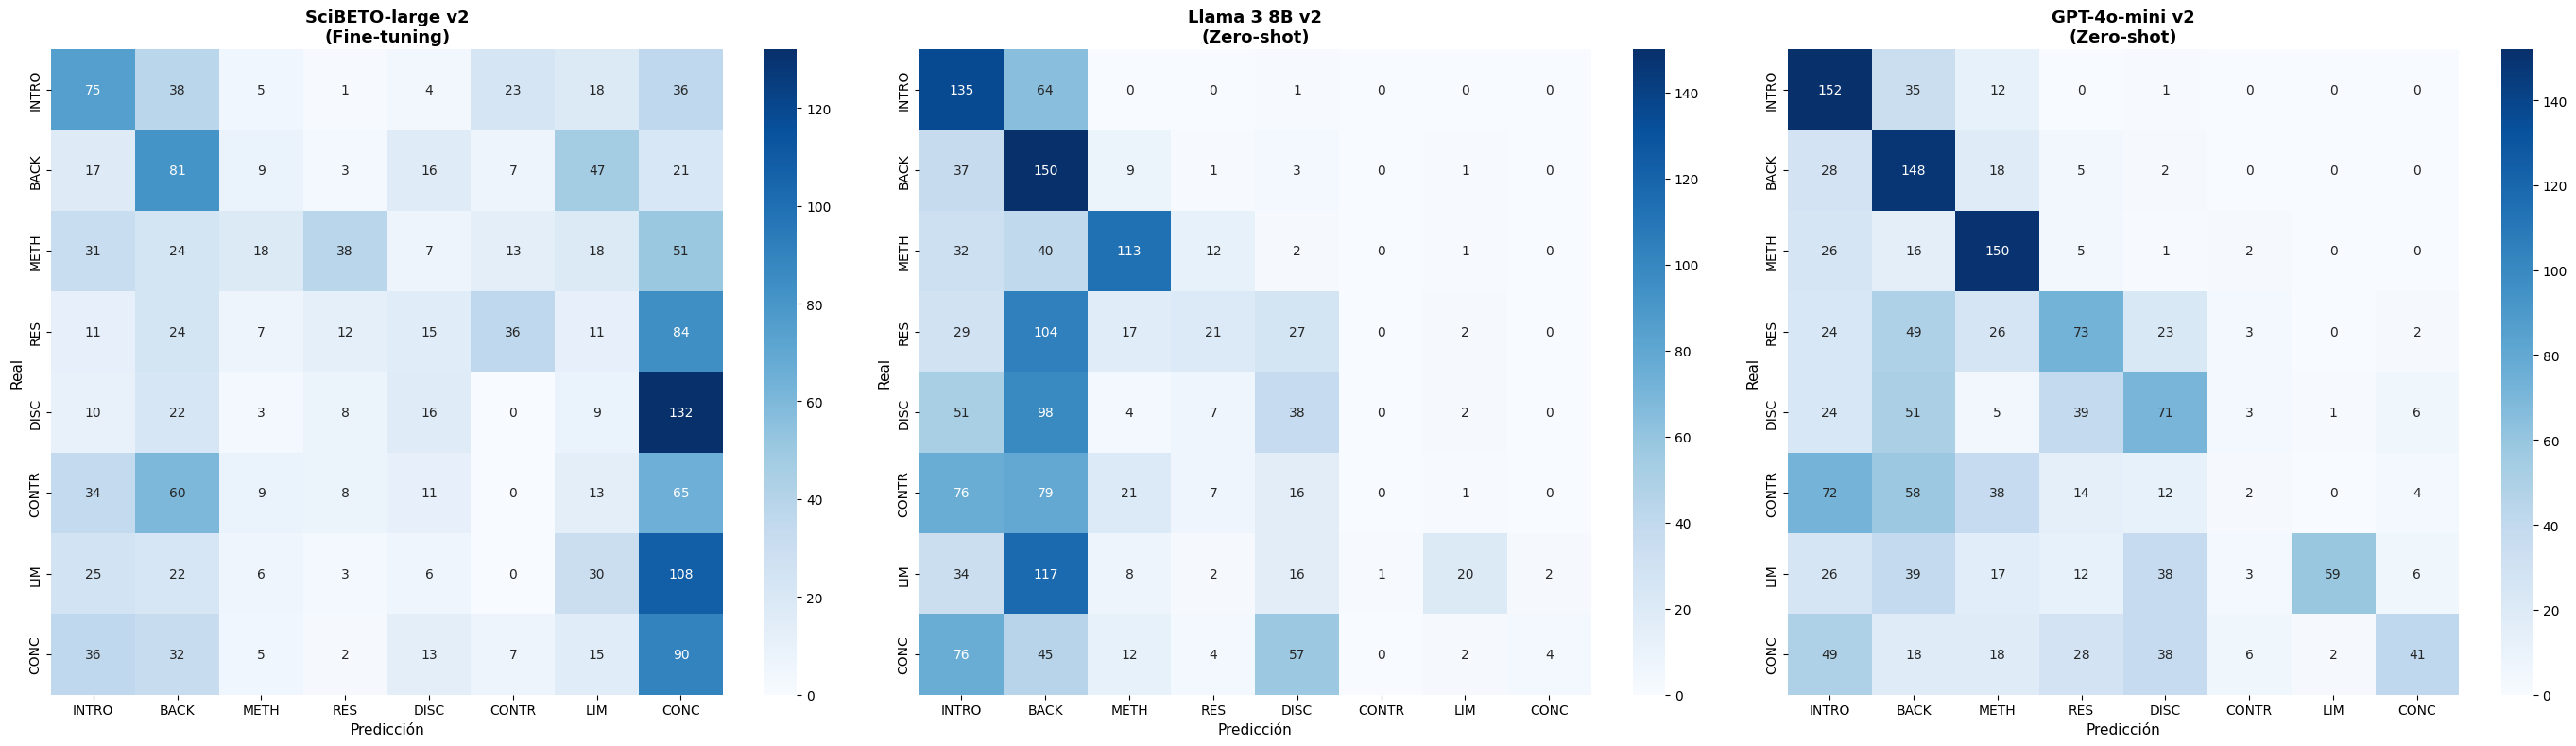

Guardado como confusion_matrices_3models.png

=== SCIBETO v2 — Reporte por categoría ===
              precision    recall  f1-score   support

       INTRO       0.31      0.38      0.34       200
        BACK       0.27      0.40      0.32       201
        METH       0.29      0.09      0.14       200
         RES       0.16      0.06      0.09       200
        DISC       0.18      0.08      0.11       200
       CONTR       0.00      0.00      0.00       200
         LIM       0.19      0.15      0.17       200
        CONC       0.15      0.45      0.23       200

    accuracy                           0.20      1601
   macro avg       0.19      0.20      0.17      1601
weighted avg       0.19      0.20      0.17      1601


=== LLAMA 3 8B v2 — Reporte por categoría ===
              precision    recall  f1-score   support

       INTRO       0.29      0.68      0.40       200
        BACK       0.22      0.75      0.33       201
        METH       0.61      0.56      0.59       

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

LABELS = ['INTRO', 'BACK', 'METH', 'RES', 'DISC', 'CONTR', 'LIM', 'CONC']

# --- Cargar predicciones ---
llama_df   = pd.read_csv('./llm_inference_results.csv')
gpt_df     = pd.read_csv('./gpt_inference_results.csv')

# --- Generar predicciones de SciBETO sobre el test set ---
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "./scibeto_final_model"
tokenizer  = AutoTokenizer.from_pretrained("Flaglab/SciBETO-large")
model      = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

test_df  = pd.read_csv('./dataset_test.csv')
label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for i, label in enumerate(LABELS)}

scibeto_preds = []
for _, row in test_df.iterrows():
    inputs = tokenizer(
        str(row['neutralized_snippet']),
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding="max_length"
    ).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    pred_id = outputs.logits.argmax(-1).item()
    scibeto_preds.append(id2label[pred_id])

scibeto_df = pd.DataFrame({
    'Actual':    test_df['category'].tolist(),
    'Predicted': scibeto_preds
})
scibeto_df.to_csv('scibeto_inference_results.csv', index=False)

# --- Matrices de confusión (3 modelos) ---
fig, axes = plt.subplots(1, 3, figsize=(28, 8))

for ax, df, title in [
    (axes[0], scibeto_df, 'SciBETO-large v2\n(Fine-tuning)'),
    (axes[1], llama_df,   'Llama 3 8B v2\n(Zero-shot)'),
    (axes[2], gpt_df,     'GPT-4o-mini v2\n(Zero-shot)')
]:
    cm = confusion_matrix(df['Actual'], df['Predicted'], labels=LABELS)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=LABELS, yticklabels=LABELS,
        ax=ax, cbar=True
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices_3models.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado como confusion_matrices_3models.png")

# --- Reporte por categoría ---
print("\n=== SCIBETO v2 — Reporte por categoría ===")
print(classification_report(scibeto_df['Actual'], scibeto_df['Predicted'], labels=LABELS))

print("\n=== LLAMA 3 8B v2 — Reporte por categoría ===")
print(classification_report(llama_df['Actual'], llama_df['Predicted'], labels=LABELS))

print("\n=== GPT-4o-mini v2 — Reporte por categoría ===")
print(classification_report(gpt_df['Actual'], gpt_df['Predicted'], labels=LABELS))

In [ ]:
from google.colab import files
files.download('dataset_train.csv')
files.download('dataset_val.csv')
files.download('dataset_test.csv')
files.download('scibeto_inference_results.csv')
files.download('gpt_inference_results.csv')
files.download('llm_inference_results.csv')
files.download('confusion_matrices_3models.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Algunas matrices rápidas (borrar este código está repetido)

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

NameError: name 'title' is not defined

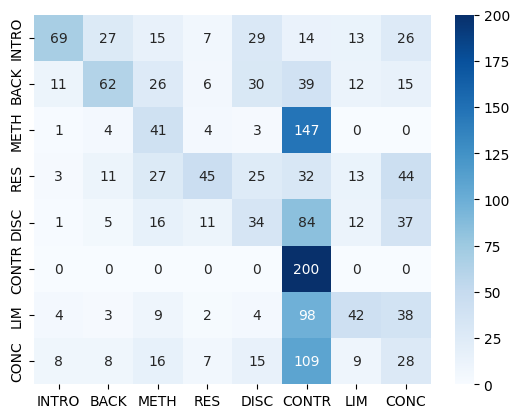

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

LABELS = ['INTRO', 'BACK', 'METH', 'RES', 'DISC', 'CONTR', 'LIM', 'CONC']

# --- Cargar predicciones ---
# llama_df   = pd.read_csv('./llm_inference_results.csv')
# gpt_df     = pd.read_csv('./gpt_inference_results.csv')

# --- Generar predicciones de SciBETO sobre el test set ---
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "./scibeto_final_model"
tokenizer  = AutoTokenizer.from_pretrained("Flaglab/SciBETO-large")
model      = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

test_df  = pd.read_csv('./dataset_test.csv')
label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for i, label in enumerate(LABELS)}

scibeto_preds = []
for _, row in test_df.iterrows():
    inputs = tokenizer(
        str(row['neutralized_snippet']),
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding="max_length"
    ).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    pred_id = outputs.logits.argmax(-1).item()
    scibeto_preds.append(id2label[pred_id])

scibeto_df = pd.DataFrame({
    'Actual':    test_df['category'].tolist(),
    'Predicted': scibeto_preds
})
scibeto_df.to_csv('scibeto_inference_results.csv', index=False)

# --- Matrices de confusión (3 modelos) ---
# fig, axes = plt.subplots(1, 3, figsize=(28, 8))

# for ax, df, title in [
#     (axes[0], scibeto_df, 'SciBETO-large v2\n(Fine-tuning)'),
#     (axes[1], llama_df,   'Llama 3 8B v2\n(Zero-shot)'),
#     (axes[2], gpt_df,     'GPT-4o-mini v2\n(Zero-shot)')
# ]:
#     cm = confusion_matrix(df['Actual'], df['Predicted'], labels=LABELS)
#     sns.heatmap(
#         cm, annot=True, fmt='d', cmap='Blues',
#         xticklabels=LABELS, yticklabels=LABELS,
#         ax=ax, cbar=True
#     )
#     ax.set_title(title, fontsize=13, fontweight='bold')
#     ax.set_xlabel('Predicción', fontsize=11)
#     ax.set_ylabel('Real', fontsize=11)

fig = plt.figure()
cm = confusion_matrix(scibeto_df['Actual'], scibeto_df['Predicted'], labels=LABELS)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=LABELS, yticklabels=LABELS,
        cbar=True
    )

plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicción', fontsize=11)
plt.ylabel('Real', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices_3models.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado como confusion_matrices_3models.png")

# --- Reporte por categoría ---
print("\n=== SCIBETO v2 — Reporte por categoría ===")
print(classification_report(scibeto_df['Actual'], scibeto_df['Predicted'], labels=LABELS))

# print("\n=== LLAMA 3 8B v2 — Reporte por categoría ===")
# print(classification_report(llama_df['Actual'], llama_df['Predicted'], labels=LABELS))

# print("\n=== GPT-4o-mini v2 — Reporte por categoría ===")
# print(classification_report(gpt_df['Actual'], gpt_df['Predicted'], labels=LABELS))

In [ ]:
cm

array([[ 69,  27,  15,   7,  29,  14,  13,  26],
       [ 11,  62,  26,   6,  30,  39,  12,  15],
       [  1,   4,  41,   4,   3, 147,   0,   0],
       [  3,  11,  27,  45,  25,  32,  13,  44],
       [  1,   5,  16,  11,  34,  84,  12,  37],
       [  0,   0,   0,   0,   0, 200,   0,   0],
       [  4,   3,   9,   2,   4,  98,  42,  38],
       [  8,   8,  16,   7,  15, 109,   9,  28]])

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

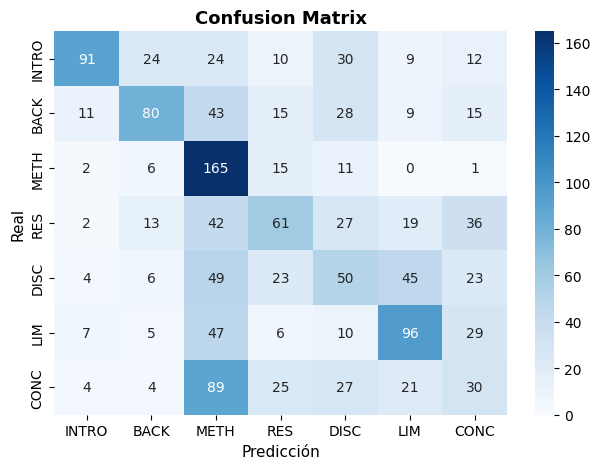

Guardado como confusion_matrices_3models.png

=== SCIBETO v2 — Reporte por categoría ===
              precision    recall  f1-score   support

       INTRO       0.75      0.46      0.57       200
        BACK       0.56      0.40      0.47       201
        METH       0.28      0.82      0.42       200
         RES       0.33      0.30      0.32       200
        DISC       0.26      0.25      0.25       200
         LIM       0.45      0.48      0.46       200
        CONC       0.20      0.15      0.17       200

   micro avg       0.36      0.41      0.38      1401
   macro avg       0.40      0.41      0.38      1401
weighted avg       0.40      0.41      0.38      1401



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

LABELS = ['INTRO', 'BACK', 'METH', 'RES', 'DISC', 'LIM', 'CONC']

# --- Cargar predicciones ---
# llama_df   = pd.read_csv('./llm_inference_results.csv')
# gpt_df     = pd.read_csv('./gpt_inference_results.csv')

# --- Generar predicciones de SciBETO sobre el test set ---
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "./scibeto_final_model"
tokenizer  = AutoTokenizer.from_pretrained("Flaglab/SciBETO-large")
model      = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

test_df  = pd.read_csv('./dataset_test.csv')
label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for i, label in enumerate(LABELS)}

scibeto_preds = []
for _, row in test_df.iterrows():
    inputs = tokenizer(
        str(row['neutralized_snippet']),
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding="max_length"
    ).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    pred_id = outputs.logits.argmax(-1).item()
    scibeto_preds.append(id2label[pred_id])

scibeto_df = pd.DataFrame({
    'Actual':    test_df['category'].tolist(),
    'Predicted': scibeto_preds
})
scibeto_df.to_csv('scibeto_inference_results.csv', index=False)

# --- Matrices de confusión (3 modelos) ---
# fig, axes = plt.subplots(1, 3, figsize=(28, 8))

# for ax, df, title in [
#     (axes[0], scibeto_df, 'SciBETO-large v2\n(Fine-tuning)'),
#     (axes[1], llama_df,   'Llama 3 8B v2\n(Zero-shot)'),
#     (axes[2], gpt_df,     'GPT-4o-mini v2\n(Zero-shot)')
# ]:
#     cm = confusion_matrix(df['Actual'], df['Predicted'], labels=LABELS)
#     sns.heatmap(
#         cm, annot=True, fmt='d', cmap='Blues',
#         xticklabels=LABELS, yticklabels=LABELS,
#         ax=ax, cbar=True
#     )
#     ax.set_title(title, fontsize=13, fontweight='bold')
#     ax.set_xlabel('Predicción', fontsize=11)
#     ax.set_ylabel('Real', fontsize=11)

fig = plt.figure()
cm = confusion_matrix(scibeto_df['Actual'], scibeto_df['Predicted'], labels=LABELS)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=LABELS, yticklabels=LABELS,
        cbar=True
    )

plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicción', fontsize=11)
plt.ylabel('Real', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices_3models.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado como confusion_matrices_3models.png")

# --- Reporte por categoría ---
print("\n=== SCIBETO v2 — Reporte por categoría ===")
print(classification_report(scibeto_df['Actual'], scibeto_df['Predicted'], labels=LABELS))

# print("\n=== LLAMA 3 8B v2 — Reporte por categoría ===")
# print(classification_report(llama_df['Actual'], llama_df['Predicted'], labels=LABELS))

# print("\n=== GPT-4o-mini v2 — Reporte por categoría ===")
# print(classification_report(gpt_df['Actual'], gpt_df['Predicted'], labels=LABELS))

In [ ]:
cm

array([[ 91,  24,  24,  10,  30,   9,  12],
       [ 11,  80,  43,  15,  28,   9,  15],
       [  2,   6, 165,  15,  11,   0,   1],
       [  2,  13,  42,  61,  27,  19,  36],
       [  4,   6,  49,  23,  50,  45,  23],
       [  7,   5,  47,   6,  10,  96,  29],
       [  4,   4,  89,  25,  27,  21,  30]])

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

LABELS = ['INTRO', 'BACK', 'METH', 'RES', 'DISC', 'LIM', 'CONC']

# --- Cargar predicciones ---
# llama_df   = pd.read_csv('./llm_inference_results.csv')
# gpt_df     = pd.read_csv('./gpt_inference_results.csv')

# --- Generar predicciones de SciBETO sobre el test set ---
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "./scibeto_final_model"
tokenizer  = AutoTokenizer.from_pretrained("Flaglab/SciBETO-large")
model      = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

test_df  = pd.read_csv('./dataset_test.csv')
label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for i, label in enumerate(LABELS)}

scibeto_preds = []
for _, row in test_df.iterrows():
    inputs = tokenizer(
        str(row['neutralized_snippet']),
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding="max_length"
    ).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    pred_id = outputs.logits.argmax(-1).item()
    scibeto_preds.append(id2label[pred_id])

scibeto_df = pd.DataFrame({
    'Actual':    test_df['category'].tolist(),
    'Predicted': scibeto_preds
})
scibeto_df.to_csv('scibeto_inference_results.csv', index=False)

# --- Matrices de confusión (3 modelos) ---
# fig, axes = plt.subplots(1, 3, figsize=(28, 8))

# for ax, df, title in [
#     (axes[0], scibeto_df, 'SciBETO-large v2\n(Fine-tuning)'),
#     (axes[1], llama_df,   'Llama 3 8B v2\n(Zero-shot)'),
#     (axes[2], gpt_df,     'GPT-4o-mini v2\n(Zero-shot)')
# ]:
#     cm = confusion_matrix(df['Actual'], df['Predicted'], labels=LABELS)
#     sns.heatmap(
#         cm, annot=True, fmt='d', cmap='Blues',
#         xticklabels=LABELS, yticklabels=LABELS,
#         ax=ax, cbar=True
#     )
#     ax.set_title(title, fontsize=13, fontweight='bold')
#     ax.set_xlabel('Predicción', fontsize=11)
#     ax.set_ylabel('Real', fontsize=11)

fig = plt.figure()
cm = confusion_matrix(scibeto_df['Actual'], scibeto_df['Predicted'], labels=LABELS)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=LABELS, yticklabels=LABELS,
        cbar=True
    )

plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicción', fontsize=11)
plt.ylabel('Real', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices_3models.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado como confusion_matrices_3models.png")

# --- Reporte por categoría ---
print("\n=== SCIBETO v2 — Reporte por categoría ===")
print(classification_report(scibeto_df['Actual'], scibeto_df['Predicted'], labels=LABELS))

# print("\n=== LLAMA 3 8B v2 — Reporte por categoría ===")
# print(classification_report(llama_df['Actual'], llama_df['Predicted'], labels=LABELS))

# print("\n=== GPT-4o-mini v2 — Reporte por categoría ===")
# print(classification_report(gpt_df['Actual'], gpt_df['Predicted'], labels=LABELS))